# 承包单细胞所有美图？这个R包就够了！
当然了，前提是我们已经掌握了使用Seurat进行单细胞分析的标准流程，然后我们就可以使用Scillus包对我们的结果进行更为丰富的可视化展示

```shell
#安装R包
if (!require(devtools)) {
 install.packages("devtools")
}
devtools::install_github("xmc811/Scillus", ref = "development")
```

In [2]:
#加载R包
library(Scillus)
library(tidyverse)
library(Seurat)
library(magrittr)
#导入数据
setwd("/Users/a1-6/Documents/projects/DL/97-bioinformatics/gene_process_for_python/single-cell-rna")
##清空环境
rm(list=ls())


Scillus 将为每个样本创建 Seurat 对象，并自动调用 PercentageFeatureSet函数来计算线粒体基因百分比。由此产生多个Seurat对象的列表，它的长度等于元数据 m 的行数

In [3]:
a <- list.files("data/GSE128531", full.names = TRUE)#获取数据集列表
#六个样本的单细胞数据（每一个样本都是标准的三个文件）
m <- tibble(file = a,  
            sample = stringr::str_remove(basename(a), ".csv.gz"), 
            group = rep(c("CTCL", "Normal"), each = 3))
## 列表的表格形式并且提供分组信息
pal <- tibble(var = c("sample", "group","seurat_clusters"), 
              pal = c("Set2","Set1","Paired"))#可视化调色盘
#读取表达数据并自动创建Seurat对象
scRNA <- load_scfile(m)
length(scRNA)



Warning message:
"Feature names cannot have underscores ('_'), replacing with dashes ('-')"
Warning message:
"Data is of class data.frame. Coercing to dgCMatrix."
Warning message:
"Feature names cannot have underscores ('_'), replacing with dashes ('-')"
Warning message:
"Data is of class data.frame. Coercing to dgCMatrix."
Warning message:
"Feature names cannot have underscores ('_'), replacing with dashes ('-')"
Warning message:
"Data is of class data.frame. Coercing to dgCMatrix."
Warning message:
"Feature names cannot have underscores ('_'), replacing with dashes ('-')"
Warning message:
"Data is of class data.frame. Coercing to dgCMatrix."
Warning message:
"Feature names cannot have underscores ('_'), replacing with dashes ('-')"
Warning message:
"Data is of class data.frame. Coercing to dgCMatrix."
Warning message:
"Feature names cannot have underscores ('_'), replacing with dashes ('-')"
Warning message:
"Data is of class data.frame. Coercing to dgCMatrix."


[1] 6

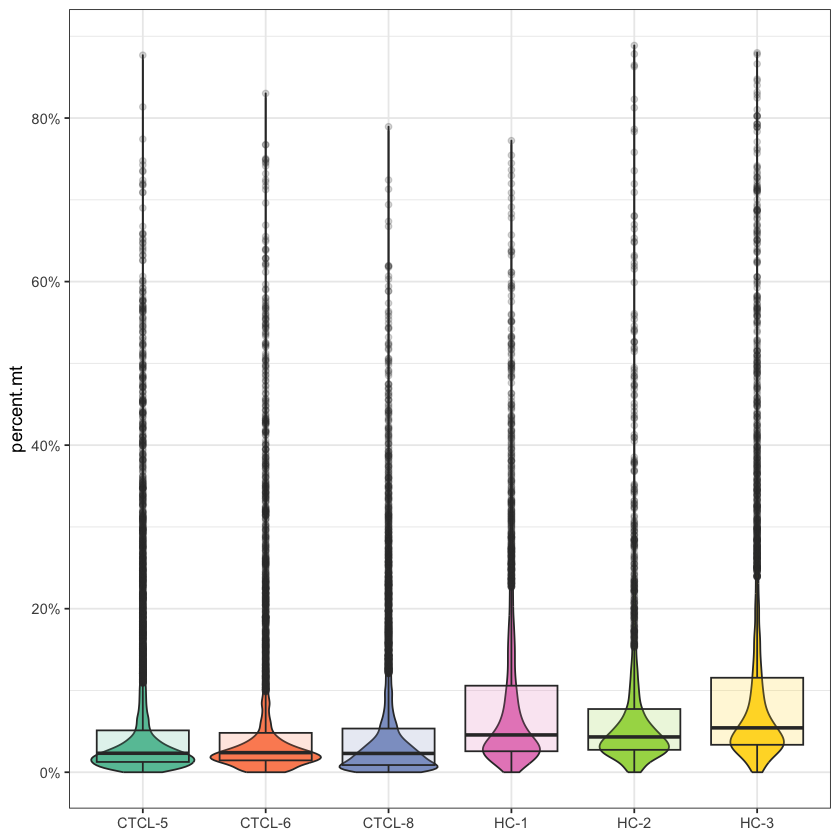

In [4]:
#展示每个样本的线粒体基因比例
plot_qc(scRNA, metrics = "percent.mt")

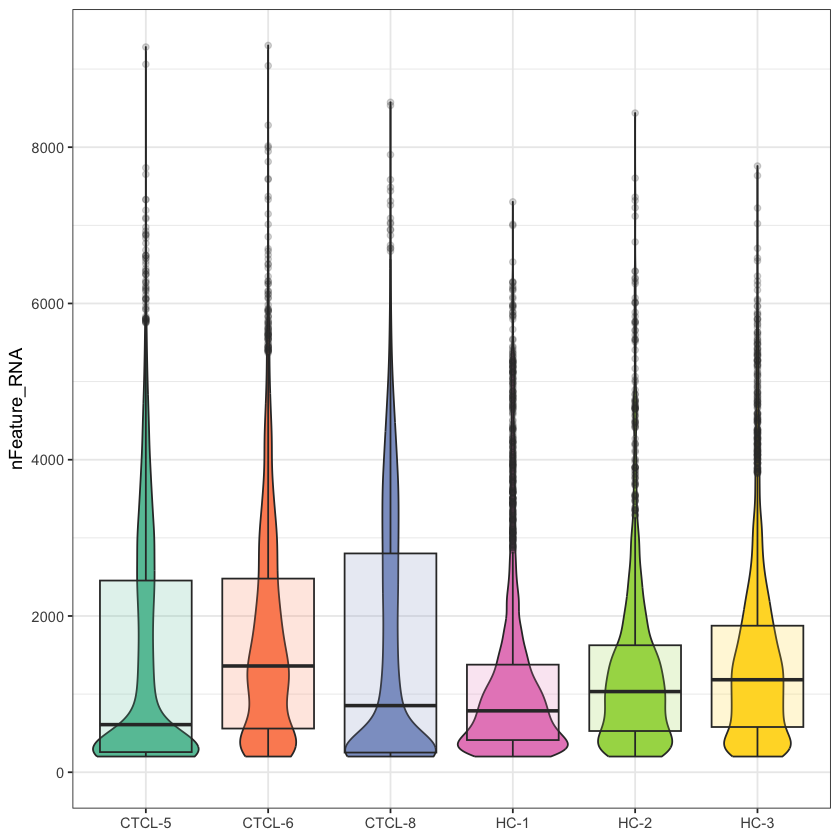

In [5]:
#展示每个样本基因的数量
plot_qc(scRNA, metrics = "nFeature_RNA")

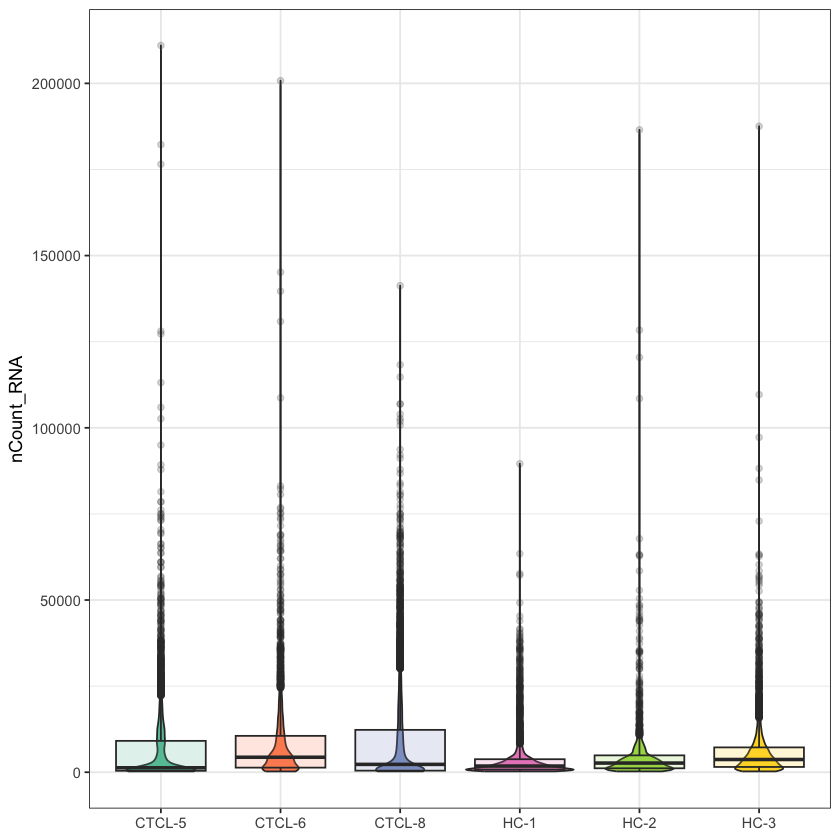

In [6]:
#展示每个样本mRNA的数量
plot_qc(scRNA, metrics = "nCount_RNA")

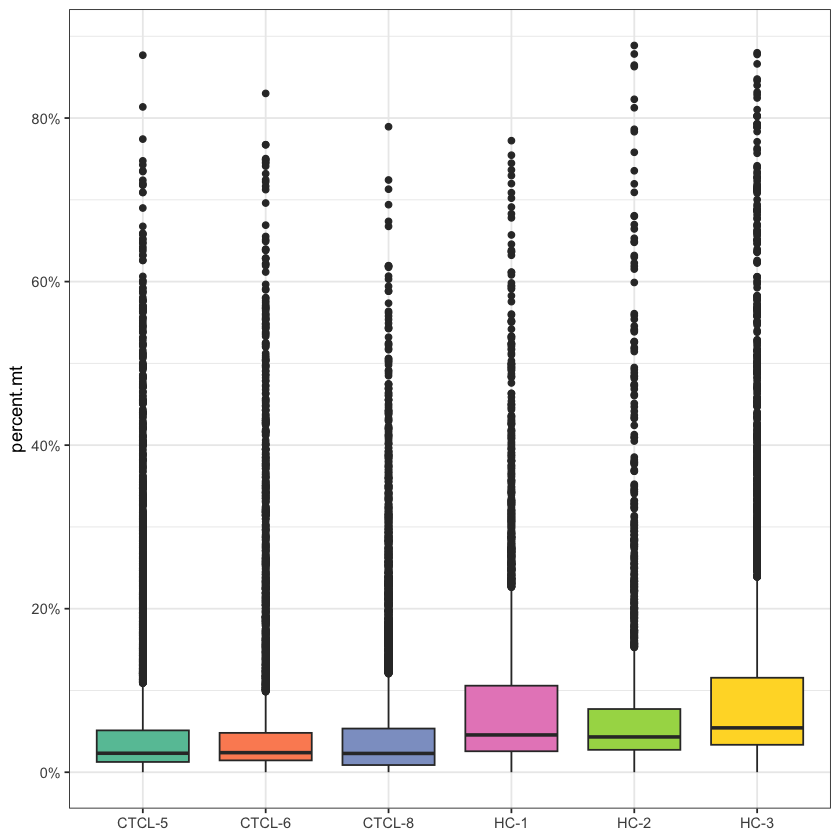

In [7]:
#展示箱线图的线粒体基因比例
plot_qc(scRNA, metrics = "percent.mt", plot_type = "box")

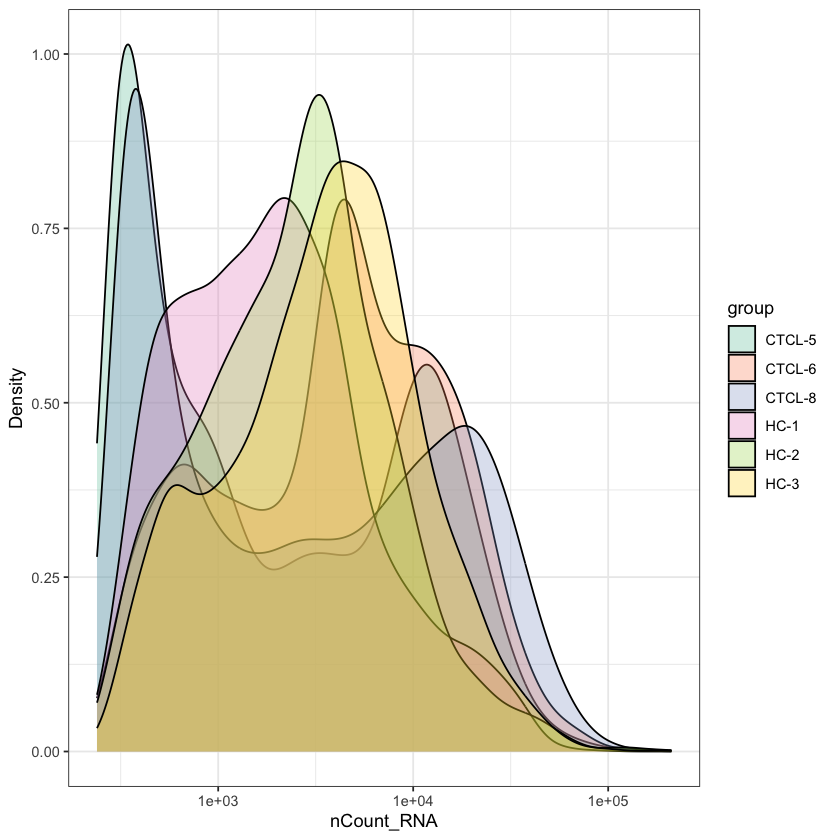

In [8]:
#展示mRNA的密度图
plot_qc(scRNA, metrics = "nCount_RNA", plot_type = "density") + scale_x_log10()


file,sample,group
<chr>,<chr>,<chr>
data/GSE128531/CTCL-5.csv.gz,CTCL-5,CTCL
data/GSE128531/CTCL-6.csv.gz,CTCL-6,CTCL
data/GSE128531/CTCL-8.csv.gz,CTCL-8,CTCL
data/GSE128531/HC-1.csv.gz,HC-1,Normal
data/GSE128531/HC-2.csv.gz,HC-2,Normal
data/GSE128531/HC-3.csv.gz,HC-3,Normal


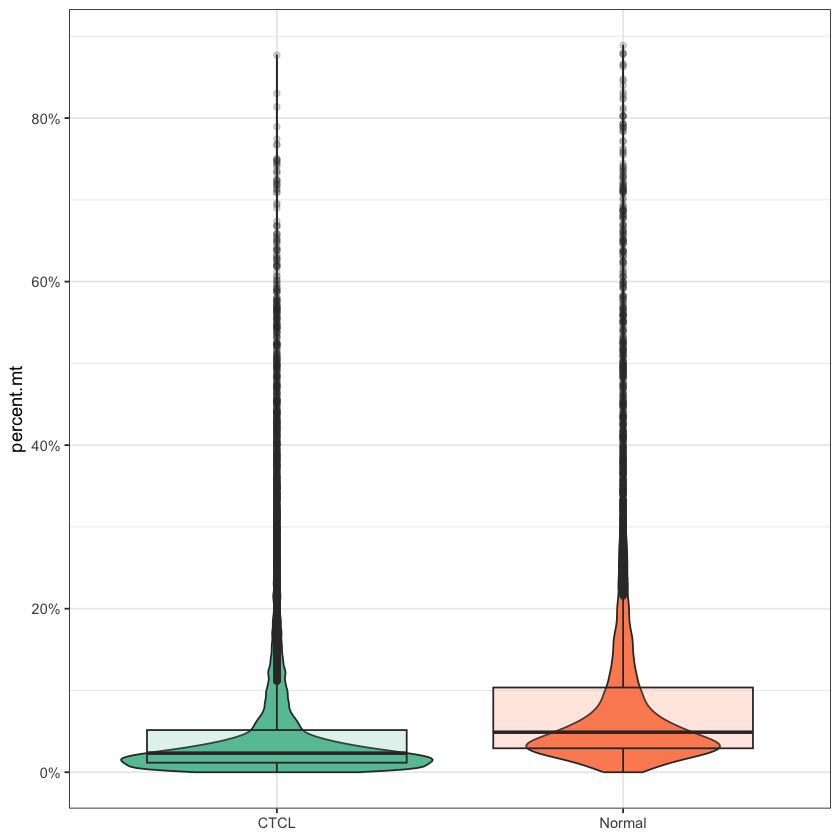

In [9]:
m
#展示不同分组下线粒体基因的比例
plot_qc(scRNA, metrics = "percent.mt", group_by = "group")

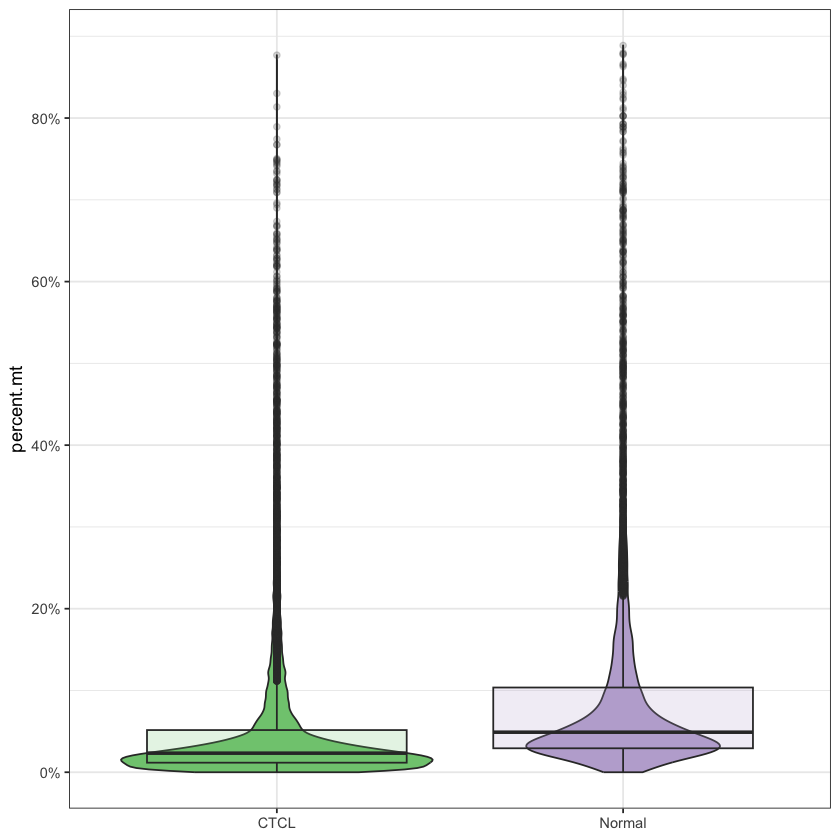

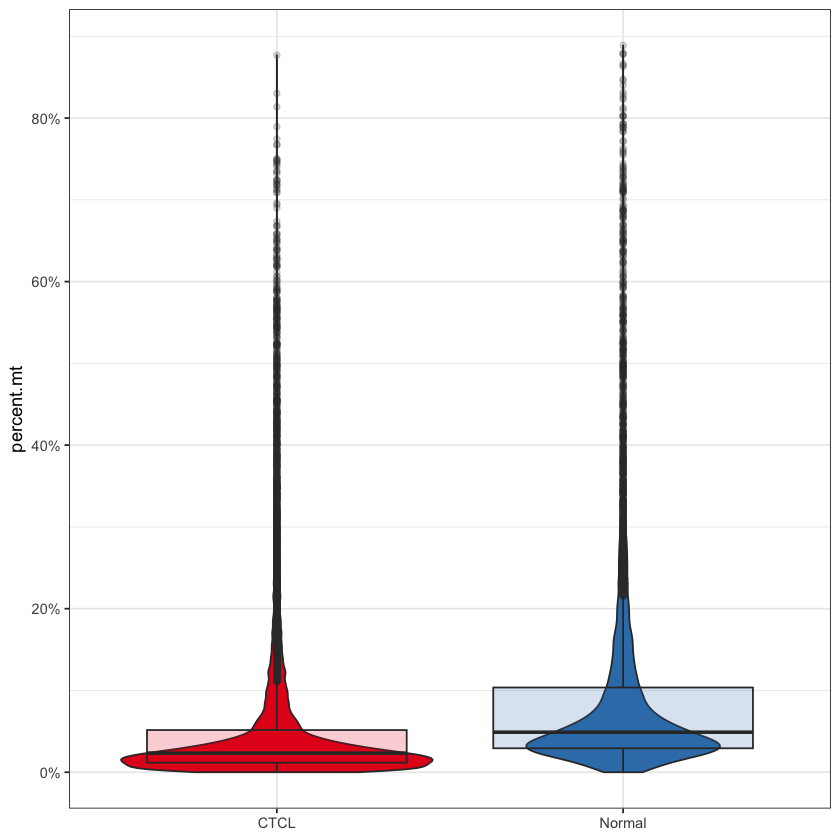

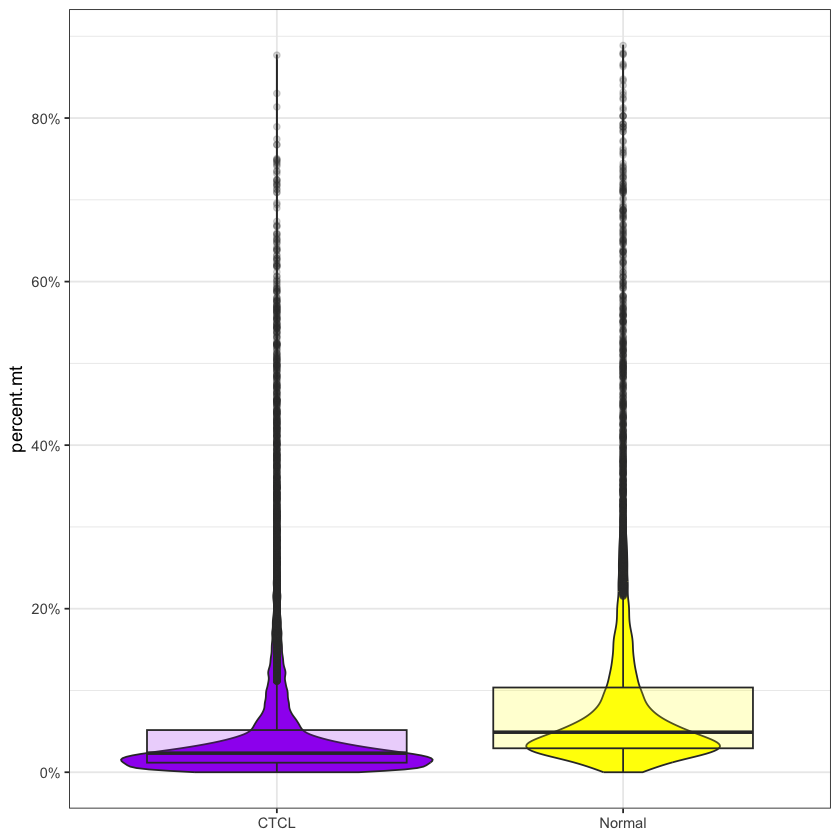

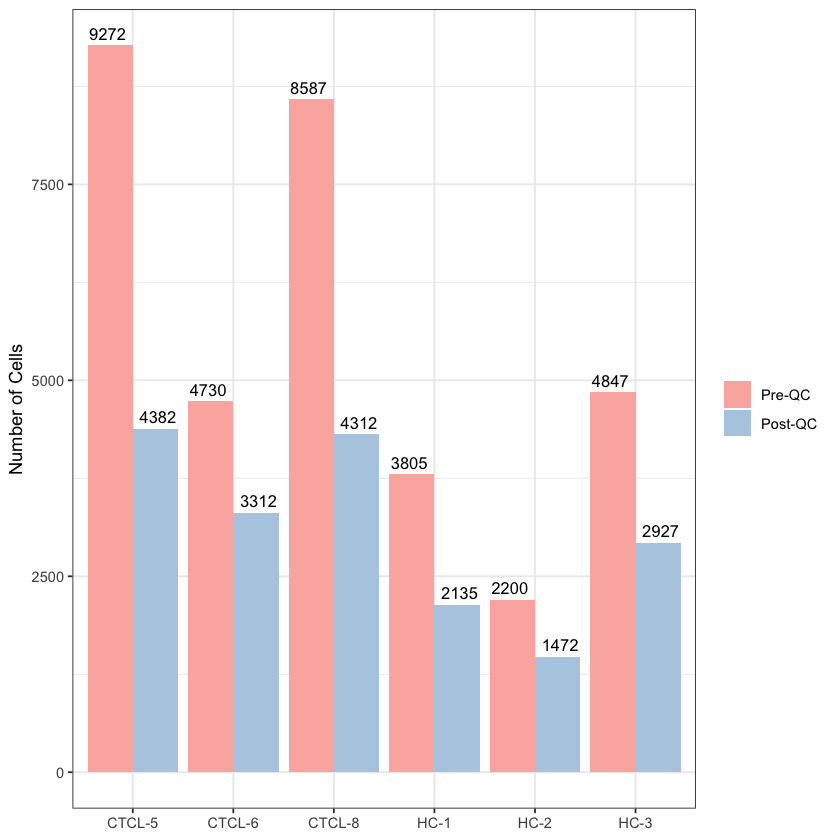

In [10]:
#当然除了上面还有一些更多展示QC方式的可视化，代码如下，各位小伙伴可以私下运行学习
plot_qc(scRNA, metrics = "percent.mt", group_by = "group", pal_setup = "Accent")
plot_qc(scRNA, metrics = "percent.mt", group_by = "group", pal_setup = pal)
plot_qc(scRNA, metrics = "percent.mt", group_by = "group", pal_setup = c("purple","yellow"))
#基于Seurat的标准piplines
scRNA_f <- filter_scdata(scRNA, subset = nFeature_RNA > 500 & percent.mt < 10)
#并且自动显示质控结果（这个功能感觉超棒）

In [ ]:
### 单细胞标准化处理流程
scRNA_f %<>% 
       purrr::map(.f = NormalizeData) %>%
       purrr::map(.f = FindVariableFeatures) %>%
       purrr::map(.f = CellCycleScoring, 
                  s.features = cc.genes$s.genes, 
                  g2m.features = cc.genes$g2m.genes)


Normalizing layer: counts

Normalizing layer: counts

Normalizing layer: counts

Normalizing layer: counts

Normalizing layer: counts

Normalizing layer: counts

Finding variable features for layer counts

Finding variable features for layer counts

Finding variable features for layer counts

Finding variable features for layer counts

Finding variable features for layer counts

Finding variable features for layer counts

Warning message:
"The following features are not present in the object: MLF1IP, not searching for symbol synonyms"
Warning message:
"The following features are not present in the object: MLF1IP, not searching for symbol synonyms"
Warning message:
"The following features are not present in the object: MLF1IP, not searching for symbol synonyms"
Warning message:
"The following features are not present in the object: MLF1IP, not searching for symbol synonyms"
Warning message:
"The following features are not present in the object: MLF1IP, not searching for symbol synonyms"

In [12]:
# 数据整合
scRNA_int <- IntegrateData(anchorset = FindIntegrationAnchors(object.list = scRNA_f, dims = 1:30, k.filter = 50), dims = 1:30)


Computing 2000 integration features

Scaling features for provided objects

Finding all pairwise anchors

Running CCA

Merging objects

Finding neighborhoods

Finding anchors

	Found 6973 anchors

Filtering anchors

	Retained 2218 anchors

Running CCA

Merging objects

Finding neighborhoods

Finding anchors

	Found 8060 anchors

Filtering anchors

	Retained 1326 anchors

Running CCA

Merging objects

Finding neighborhoods

Finding anchors

	Found 5176 anchors

Filtering anchors

	Retained 1397 anchors

Running CCA

Merging objects

Finding neighborhoods

Finding anchors

	Found 5026 anchors

Filtering anchors

	Retained 989 anchors

Running CCA

Merging objects

Finding neighborhoods

Finding anchors

	Found 3652 anchors

Filtering anchors

	Retained 1287 anchors

Running CCA

Merging objects

Finding neighborhoods

Finding anchors

	Found 4372 anchors

Filtering anchors

	Retained 1555 anchors

Running CCA

Merging objects

Finding neighborhoods

Finding anchors

	Found 4093 anchors



In [13]:
scRNA_int %<>%
       ScaleData(vars.to.regress = c("nCount_RNA", "percent.mt", "S.Score", "G2M.Score"))
scRNA_int %<>%
       RunPCA(npcs = 50, verbose = TRUE)
#%>% 管道符号不赋值就只是给你看看
#%<>% 结果自动进行赋值
scRNA_int %<>%
       RunUMAP(reduction = "pca", dims = 1:20, n.neighbors = 30) %>%
       FindNeighbors(reduction = "pca", dims = 1:20) %>%
       FindClusters(resolution = 0.3)

Regressing out nCount_RNA, percent.mt, S.Score, G2M.Score

Centering and scaling data matrix

PC_ 1 
Positive:  IGFBP7, SPARC, ADIRF, IGFBP4, MGP, SPARCL1, GSN, TIMP3, GNG11, AQP1 
	   SERPING1, SELM, PLPP3, PMP22, TIMP2, TCF4, CST3, COL1A2, FSTL1, COL6A2 
	   COL6A1, LHFP, PLAC9, MYL9, NNMT, A2M, EMCN, PRKCDBP, PTRF, SOD3 
Negative:  AQP3, SFN, TACSTD2, S100A14, SERPINB5, LGALS7B, CLDN1, PERP, DMKN, DSC3 
	   LYPD3, DSP, IRF6, LY6D, FXYD3, KLF5, SERPINB2, LGALS7, KRTDAP, DENND2C 
	   KRT1, DSG1, SBSN, TRIM29, FGFBP1, CSTA, KLK11, DAPL1, MAL2, EHF 
PC_ 2 
Positive:  NUPR1, EMP2, CXCL14, PERP, GPNMB, CRABP2, EMP1, S100A16, YBX3, CLDN1 
	   RND3, KRT10, S100A14, CAV1, CLTB, MT1X, KLF4, GSN, APOE, SERPINB5 
	   TACSTD2, DMKN, PTRF, IRF6, SFN, LGALS7B, DSP, TMEM45A, HES1, CRYAB 
Negative:  SRGN, CREM, GPR183, LAPTM5, GLIPR1, SAMSN1, TRAF1, CXCR4, CYTIP, PTPRC 
	   CD48, HCST, INSIG1, CD74, ALOX5AP, BIRC3, DUSP4, HLA-DQB1, TYROBP, TNFRSF9 
	   GPAT3, COTL1, CLEC2D, KLRB1, GPR65, CORO1A, BCL

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 18540
Number of edges: 625449

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9501
Number of communities: 13
Elapsed time: 1 seconds


上面这个piplines就可以帮助我们完成scRNA-seq多数据集联合，而且重点是这个piplines是可以复制的



在 R 语言的 dplyr 包中，mutate() 函数用于添加新列或修改已有列，而不会改变原始数据的行数。它的核心作用是按列计算并返回新的数据框。

In [14]:
#我们把元数据的分组信息提取出来，方便我们后续作图
m
m %<>%
       mutate(group = factor(group, levels = c("CTCL","Normal")))
m

file,sample,group
<chr>,<chr>,<chr>
data/GSE128531/CTCL-5.csv.gz,CTCL-5,CTCL
data/GSE128531/CTCL-6.csv.gz,CTCL-6,CTCL
data/GSE128531/CTCL-8.csv.gz,CTCL-8,CTCL
data/GSE128531/HC-1.csv.gz,HC-1,Normal
data/GSE128531/HC-2.csv.gz,HC-2,Normal
data/GSE128531/HC-3.csv.gz,HC-3,Normal


file,sample,group
<chr>,<chr>,<fct>
data/GSE128531/CTCL-5.csv.gz,CTCL-5,CTCL
data/GSE128531/CTCL-6.csv.gz,CTCL-6,CTCL
data/GSE128531/CTCL-8.csv.gz,CTCL-8,CTCL
data/GSE128531/HC-1.csv.gz,HC-1,Normal
data/GSE128531/HC-2.csv.gz,HC-2,Normal
data/GSE128531/HC-3.csv.gz,HC-3,Normal


In [ ]:
## 通过refactor_seurat()对Seurat对象的metadata数据进行因子化是一个可选步骤,主要用于改善绘图效果。
scRNA_int %<>%
       refactor_seurat(metadata = m)

In [21]:
str(scRNA_int@reductions$umap@cell.embeddings)

 num [1:18540, 1:2] -10.46 9.58 5.39 -2.65 7.88 ...
 - attr(*, "scaled:center")= num [1:2] 0.648 -0.103
 - attr(*, "dimnames")=List of 2
  ..$ : chr [1:18540] "SC82mf5_AAACCTGCATCAGTAC" "SC82mf5_AAACGGGAGTCCCACG" "SC82mf5_AAACGGGAGTCCGTAT" "SC82mf5_AAACGGGAGTGTACGG" ...
  ..$ : chr [1:2] "umap_1" "umap_2"


In [22]:
colnames(scRNA_int@reductions$umap@cell.embeddings)

[1] "umap_1" "umap_2"

报错，列名不正确            
ERROR while rich displaying an object: Error in `geom_point()`:    
! Problem while computing aesthetics.   
i Error occurred in the 1st layer.   
Caused by error in `.data$UMAP_1`:  

In [24]:
umap_coords <- scRNA_int@reductions$umap@cell.embeddings
colnames(umap_coords) <- c("UMAP_1", "UMAP_2")

In [27]:
# 将新坐标存回对象
scRNA_int@reductions$umap@cell.embeddings <- umap_coords

In [26]:
colnames(umap_coords)

[1] "UMAP_1" "UMAP_2"

Warning message in set_colors(pal, length(unique(df[[color_by]]))):
"Number of colors required exceeds palette capacity. RdYlBu spectrum will be used instead."


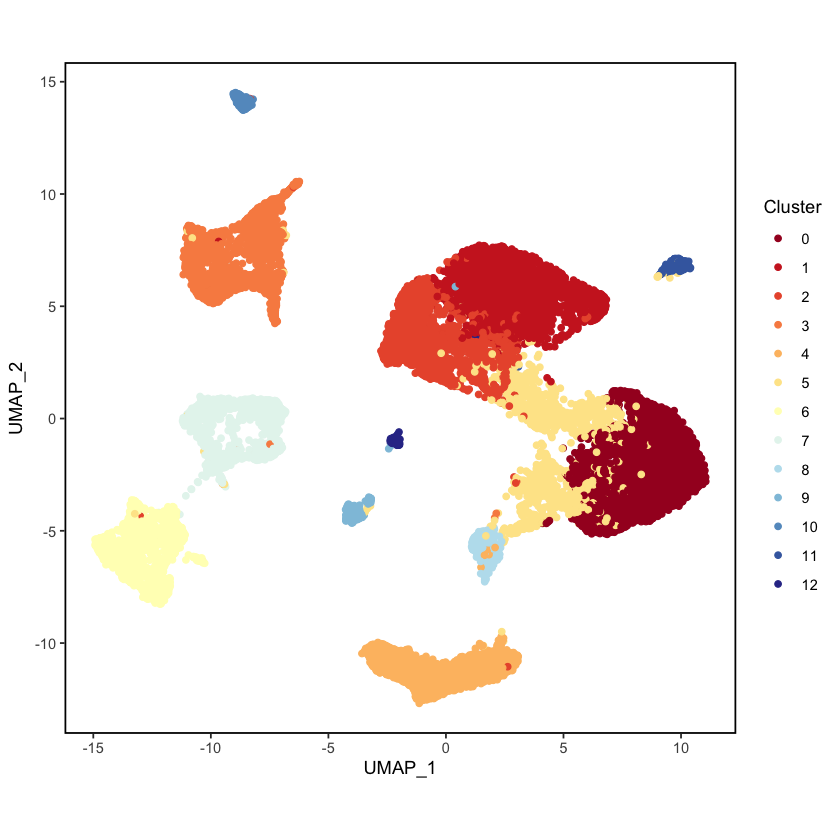

In [28]:
#可视化案例1
plot_scdata(scRNA_int, pal_setup = pal)

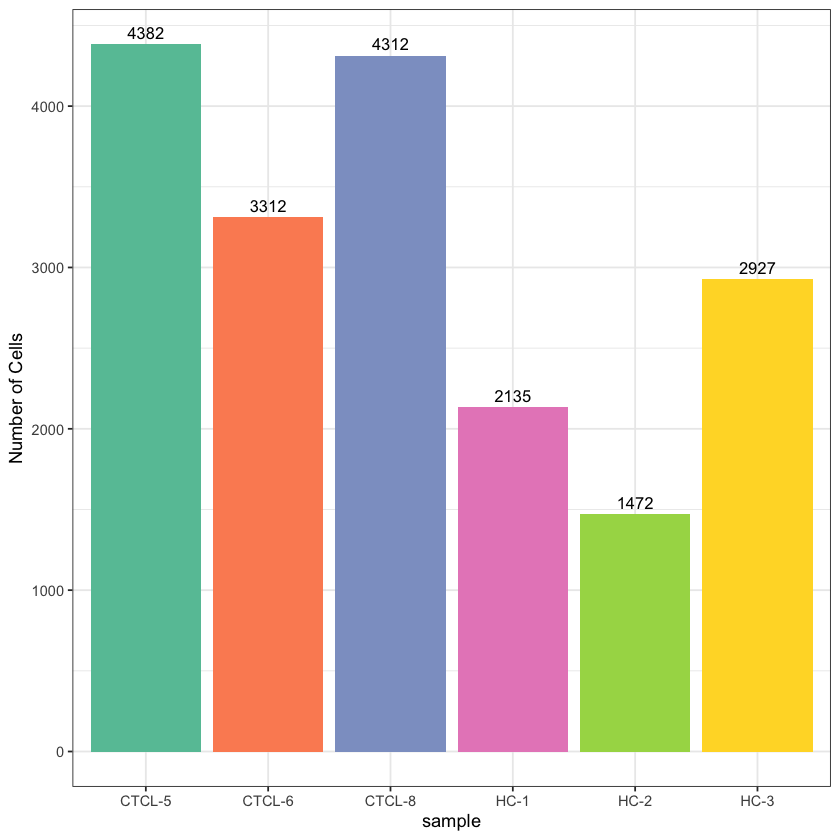

In [29]:
#可视化案例2
plot_stat(scRNA_int, plot_type = "group_count")

Calculating cluster 0

Warning message in mean.fxn(object[features, cells.1, drop = FALSE]):
"NaNs produced"
For a (much!) faster implementation of the Wilcoxon Rank Sum Test,
(default method for FindMarkers) please install the presto package
--------------------------------------------
install.packages('devtools')
devtools::install_github('immunogenomics/presto')
--------------------------------------------
After installation of presto, Seurat will automatically use the more 
efficient implementation (no further action necessary).
This message will be shown once per session

Calculating cluster 1

Warning message in mean.fxn(object[features, cells.1, drop = FALSE]):
"NaNs produced"
Calculating cluster 2

Warning message in mean.fxn(object[features, cells.1, drop = FALSE]):
"NaNs produced"
Calculating cluster 3

Warning message in mean.fxn(object[features, cells.1, drop = FALSE]):
"NaNs produced"
Warning message in mean.fxn(object[features, cells.2, drop = FALSE]):
"NaNs produced"
Calc

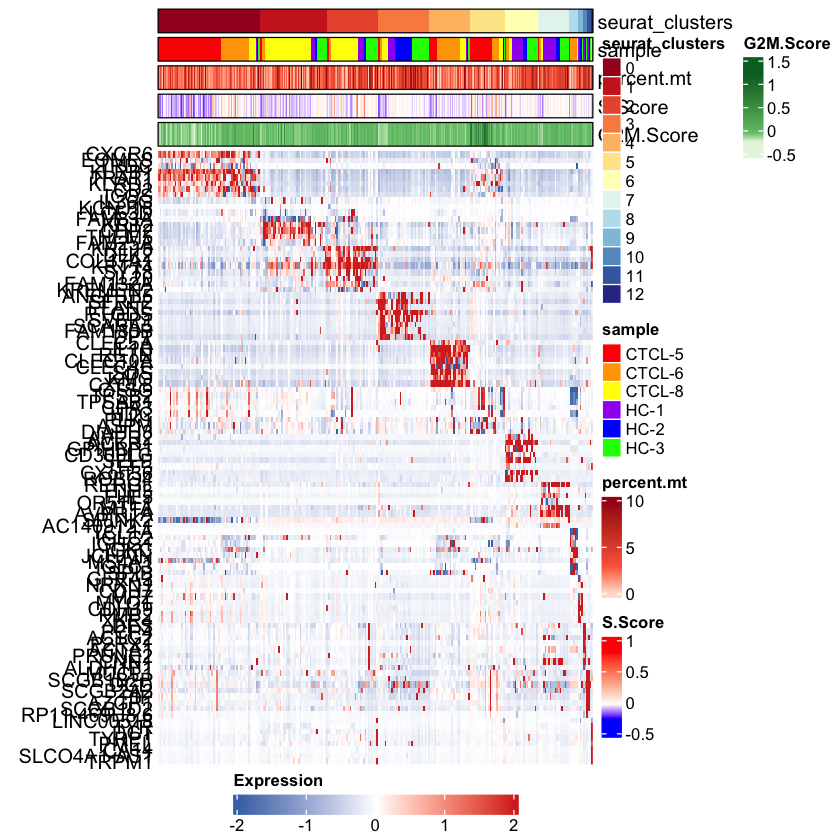

In [30]:
#可视化案例3
markers <- FindAllMarkers(scRNA_int, logfc.threshold = 0.1, min.pct = 0, only.pos = T)
plot_heatmap(dataset = scRNA_int, 
            markers = markers,
            sort_var = c("seurat_clusters","sample"),
            anno_var = c("seurat_clusters","sample","percent.mt","S.Score","G2M.Score"),
            anno_colors = list("Set2",                                             # RColorBrewer palette
                               c("red","orange","yellow","purple","blue","green"), # color vector
                               "Reds",
                               c("blue","white","red"),                            # Three-color gradient
                               "Greens"))

In [49]:
slotNames(scRNA_int[["integrated"]])

[1] "counts"        "data"          "scale.data"    "assay.orig"   
[5] "var.features"  "meta.features" "misc"          "key"

In [39]:
#可视化案例4
library(org.Hs.eg.db)
plot_cluster_go(markers, cluster_name = "1", org = "human", ont = "CC")

Loading required package: AnnotationDbi

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: 'BiocGenerics'


The following object is masked from 'package:SeuratObject':

    intersect


The following objects are masked from 'package:lubridate':

    intersect, setdiff, union


The following objects are masked from 'package:dplyr':

    combine, intersect, setdiff, union


The following objects are masked from 'package:stats':

    IQR, mad, sd, var, xtabs


The following objects are masked from 'package:base':

    Filter, Find, Map, Position, Reduce, anyDuplicated, aperm, append,
    as.data.frame, basename, cbind, colnames, dirname, do.call,
    duplicated, eval, evalq, get, grep, grepl, intersect, is.unsorted,
    lapply, mapply, match, mget, order, paste, pmax, pmax.int, pmin,
    pmin.int, rank, rbind, rownames, sapply, saveRDS, setdiff, table,
    tapply, union, unique, unsplit, which.max, which.min


Loading required package: Biobase

W

ERROR: Error: Package "clusterProfiler" needed for this function to work. Please install it.


In [38]:
Layers(scRNA_int[["RNA"]]) 

[1] "counts.CTCL-5"     "counts.CTCL-6"     "counts.CTCL-8"    
 [4] "counts.HC-1"       "counts.HC-2"       "counts.HC-3"      
 [7] "data.CTCL-5"       "scale.data.CTCL-5" "data.CTCL-6"      
[10] "scale.data.CTCL-6" "data.CTCL-8"       "scale.data.CTCL-8"
[13] "data.HC-1"         "scale.data.HC-1"   "data.HC-2"        
[16] "scale.data.HC-2"   "data.HC-3"         "scale.data.HC-3"

In [53]:
#可视化案例5

markers <- FindAllMarkers(scRNA_int, 
                         logfc.threshold = 0.1, 
                         min.pct = 0, 
                         only.pos = T)
de <- find_diff_genes(dataset = scRNA_int, 
                     clusters = as.character(0:6),
                     comparison = c("group", "CTCL", "Normal"),
                     logfc.threshold = 0,   # threshold of 0 is used for GSEA
                     min.cells.group = 1)   # To include clusters with only 1 cell
gsea_res <- test_GSEA(de, 
                     pathway = pathways.hallmark)
plot_GSEA(gsea_res, p_cutoff = 0.1, colors = c("#0570b0", "grey", "#d7301f"))

Calculating cluster 0

Warning message in mean.fxn(object[features, cells.1, drop = FALSE]):
"NaNs produced"
Calculating cluster 1

Warning message in mean.fxn(object[features, cells.1, drop = FALSE]):
"NaNs produced"
Calculating cluster 2

Warning message in mean.fxn(object[features, cells.1, drop = FALSE]):
"NaNs produced"
Calculating cluster 3

Warning message in mean.fxn(object[features, cells.1, drop = FALSE]):
"NaNs produced"
Warning message in mean.fxn(object[features, cells.2, drop = FALSE]):
"NaNs produced"
Calculating cluster 4

Warning message in mean.fxn(object[features, cells.1, drop = FALSE]):
"NaNs produced"
Warning message in mean.fxn(object[features, cells.2, drop = FALSE]):
"NaNs produced"
Calculating cluster 5

Warning message in mean.fxn(object[features, cells.1, drop = FALSE]):
"NaNs produced"
Warning message in mean.fxn(object[features, cells.2, drop = FALSE]):
"NaNs produced"
Calculating cluster 6

Warning message in mean.fxn(object[features, cells.1, drop = FALS

ERROR: Error in FindMarkers.StdAssay(object = data.use, latent.vars = latent.vars, : data layers are not joined. Please run JoinLayers
